In [46]:
# Analysis of Stock Movement of 10%+ in S&P 500 

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from datetime import datetime, timedelta
from io import StringIO
import requests

In [47]:
# Config

THRESHOLD = 0.10      # this is the minimum amount a stock needs to move to trigger an event (%)
HOLD_DAYS = 5         # the no. of trading days to measure returns after an event

In [48]:
# Pulling the Tickers

def get_sp500_tickers():
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    response = requests.get(url, headers=headers)
    tables = pd.read_html(StringIO(response.text))
    sp500_table = tables[0]
    tickers = sp500_table['Symbol'].tolist()
    tickers = [ticker.replace('.', '-') for ticker in tickers]
    return tickers

In [49]:
# Data Collection

def download_stock_data(tickers, start_date, end_date):
    print(f"Downloading data for {len(tickers)} stocks...")
    return yf.download(tickers, start=start_date, end=end_date, progress=True, group_by='ticker')


def download_spy(start_date, end_date):
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    spy.index = pd.to_datetime(spy.index)
    return spy

In [50]:
# Detecting Events (10% Changes)

def analyze_stock(ticker, df, threshold, hold_days):
    events = []
    df = df.copy()
    df['Return'] = df['Close'].pct_change()

    for event_date, row in df[abs(df['Return']) >= threshold].iterrows():
        pos = df.index.get_loc(event_date)
        event_close = row['Close']

        next_day_return = None
        if pos + 1 < len(df):
            next_day_return = (df.iloc[pos + 1]['Close'] - event_close) / event_close * 100

        next_week_return = None
        if pos + hold_days < len(df):
            next_week_return = (df.iloc[pos + hold_days]['Close'] - event_close) / event_close * 100

        events.append({
            'ticker': ticker,
            'date': event_date,
            'move_pct': row['Return'] * 100,
            'move_type': 'gain' if row['Return'] > 0 else 'drop',
            'next_day_return': next_day_return,
            'next_week_return': next_week_return,
        })

    return events


def build_events_df(tickers, data, threshold, hold_days):
    all_events = []

    for i in range(len(tickers)):
        ticker = tickers[i]
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{len(tickers)} stocks...")
        try:
            stock_data = data[ticker].copy() if isinstance(data.columns, pd.MultiIndex) else data.copy()
            if len(stock_data) < 10:
                continue
            all_events.extend(analyze_stock(ticker, stock_data, threshold, hold_days))
        except:
            continue

    df = pd.DataFrame(all_events).dropna(subset=['next_day_return', 'next_week_return'])
    print(f"Found {len(df)} qualifying events\n")
    return df

In [51]:
# Analysis of Strategy (Buying 10%+ Losses)

def add_spy_excess_returns(drops, spy):
    drops = drops.copy()
    drops['date'] = pd.to_datetime(drops['date'])

    def spy_return_after(event_date):
        try:
            pos = spy.index.get_loc(event_date)
            if pos + HOLD_DAYS < len(spy):
                return (spy.iloc[pos + HOLD_DAYS]['Close'] - spy.iloc[pos]['Close']) / spy.iloc[pos]['Close'] * 100
        except:
            return None

    drops['spy_next_week'] = drops['date'].apply(spy_return_after)
    drops['excess_return'] = drops['next_week_return'] - drops['spy_next_week']
    return drops


def binomial_test(series, label):
    n = len(series)
    k = int((series > 0).sum())
    result = stats.binomtest(k, n, p=0.5)
    ci = result.proportion_ci()
    print(f"{label}")
    print(f"n={n}  |  up={k} ({k/n*100:.1f}%)  |  p={result.pvalue:.4f}  |  95% CI: [{ci.low:.3f}, {ci.high:.3f}]")
    return result


def kelly(win_rate, avg_win, avg_loss):
    return win_rate / avg_loss - (1 - win_rate) / avg_win


def run_analysis(events_df, spy):
    gains = events_df[events_df['move_type'] == 'gain']
    drops = events_df[events_df['move_type'] == 'drop']
    drops = add_spy_excess_returns(drops, spy)

    # Summary
    print("-" * 65)
    print("SUMMARY")
    print("-" * 65)
    print(f"Total events: {len(events_df)}")
    print(f"Large gains: {len(gains)}")
    print(f"Large drops: {len(drops)}")

    # Gains
    print("\n" + "-" * 65)
    print("AFTER 10%+ GAINS")
    print("-" * 65)
    print(f"Next day (avg): {gains['next_day_return'].mean():.2f}%  |  up: {(gains['next_day_return'] > 0).mean()*100:.1f}%")
    print(f"Next week (avg): {gains['next_week_return'].mean():.2f}%  |  up: {(gains['next_week_return'] > 0).mean()*100:.1f}%")

    # Drops
    print("\n" + "-" * 65)
    print("AFTER 10%+ DROPS")
    print("-" * 65)
    print(f"Next day (avg): {drops['next_day_return'].mean():.2f}%  |  up: {(drops['next_day_return'] > 0).mean()*100:.1f}%")
    print(f"Next week (avg): {drops['next_week_return'].mean():.2f}%  |  up: {(drops['next_week_return'] > 0).mean()*100:.1f}%")

    # Statistical significance
    print("\n" + "-" * 65)
    print("STATISTICAL SIGNIFICANCE (binomial test vs 50%)")
    print("-" * 65)
    binomial_test(drops['next_week_return'], "Raw next-week win rate")

    # SPY-adjusted
    print("\n" + "-" * 65)
    print("SPY-ADJUSTED RETURNS")
    print("-" * 65)
    print(f"Mean raw return: {drops['next_week_return'].mean():.2f}%")
    print(f"Mean SPY (same window): {drops['spy_next_week'].mean():.2f}%")
    print(f"Mean excess return: {drops['excess_return'].mean():.2f}%")

    # Trade metrics
    wins_mask = drops['next_week_return'] > 0
    avg_win = drops.loc[wins_mask, 'next_week_return'].mean()
    avg_loss = drops.loc[~wins_mask, 'next_week_return'].mean()
    win_rate = wins_mask.mean()
    ev = win_rate * avg_win + (1 - win_rate) * avg_loss
    k_full = kelly(win_rate, avg_win, abs(avg_loss))
    k_half = k_full / 2
    num_drops = len(drops)
    expected_year_gain = (1 + ((ev / 100) * k_half)) ** num_drops

    print("\n" + "-" * 65)
    print("TRADE METRICS")
    print("-" * 65)
    print(f"Win rate: {win_rate*100:.1f}%")
    print(f"Avg win: +{avg_win:.2f}%")
    print(f"Avg loss: {avg_loss:.2f}%")
    print(f"Largest gain: +{drops['next_week_return'].max():.2f}%")
    print(f"Largest loss: {drops['next_week_return'].min():.2f}%")
    print(f"Expected value / trade: {ev:.2f}%")
    print(f"Half Kelly sizing (recommended): {k_half*100:.1f}% of portfolio per trade")
    print(f"Expected Yearly Gain on Strategy: {(expected_year_gain - 1) * 100:.1f}%")

In [52]:
# Visuals

def create_visualizations(events_df):
    gains = events_df[events_df['move_type'] == 'gain']
    drops = events_df[events_df['move_type'] == 'drop']

    # 2x2 return distribution grid
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('S&P 500: Returns After Large Single-Day Moves (10%+)', fontsize=15, fontweight='bold')

    plots = [
        (axes[0, 0], gains['next_day_return'], 'green', 'After 10%+ GAIN (Next Day)'),
        (axes[0, 1], drops['next_day_return'], 'red', 'After 10%+ DROP (Next Day)'),
        (axes[1, 0], gains['next_week_return'], 'green', 'After 10%+ GAIN (Next Week)'),
        (axes[1, 1], drops['next_week_return'], 'red', 'After 10%+ DROP (Next Week)'),
    ]
    for ax, series, color, title in plots:
        ax.hist(series, bins=50, alpha=0.7, color=color, edgecolor='black')
        ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='0%')
        ax.axvline(series.mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean: {series.mean():.2f}%')
        ax.set_title(title)
        ax.set_xlabel('Return (%)')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Win rate bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Win Rate: % of Stocks That Rose After Large Moves', fontsize=14, fontweight='bold')

    for ax, subset, color, ref_color, title in [
        (axes[0], gains, 'green', 'red', 'After 10%+ GAIN'),
        (axes[1], drops, 'red', 'green', 'After 10%+ DROP'),
    ]:
        rates = [
            (subset['next_day_return']  > 0).mean() * 100,
            (subset['next_week_return'] > 0).mean() * 100,
        ]
        axes_x = ['Next Day', 'Next Week']
        ax.bar(axes_x, rates, color=color, alpha=0.7, edgecolor='black')
        ax.axhline(50, color=ref_color, linestyle='--', linewidth=2, label='50% (random)')
        ax.set_ylim([0, 100])
        ax.set_ylabel('% Stocks That Rose')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        for i in range(len(rates)):
            v = rates[i]
            ax.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

-----------------------------------------------------------------
S&P 500 LARGE MOVEMENT ANALYSIS
-----------------------------------------------------------------



[                       0%                       ]

Fetched 503 tickers



[*********************100%***********************]  503 of 503 completed


Processed 50/503 stocks...
Processed 100/503 stocks...
Processed 150/503 stocks...
Processed 200/503 stocks...
Processed 250/503 stocks...
Processed 300/503 stocks...
Processed 350/503 stocks...
Processed 400/503 stocks...
Processed 450/503 stocks...
Processed 500/503 stocks...
Found 505 qualifying events

-----------------------------------------------------------------
SUMMARY
-----------------------------------------------------------------
Total events: 505
Large gains: 274
Large drops: 231

-----------------------------------------------------------------
AFTER 10%+ GAINS
-----------------------------------------------------------------
Next day (avg): 0.58%  |  up: 52.2%
Next week (avg): 1.47%  |  up: 55.1%

-----------------------------------------------------------------
AFTER 10%+ DROPS
-----------------------------------------------------------------
Next day (avg): 0.81%  |  up: 56.7%
Next week (avg): 2.00%  |  up: 58.9%

-----------------------------------------------------

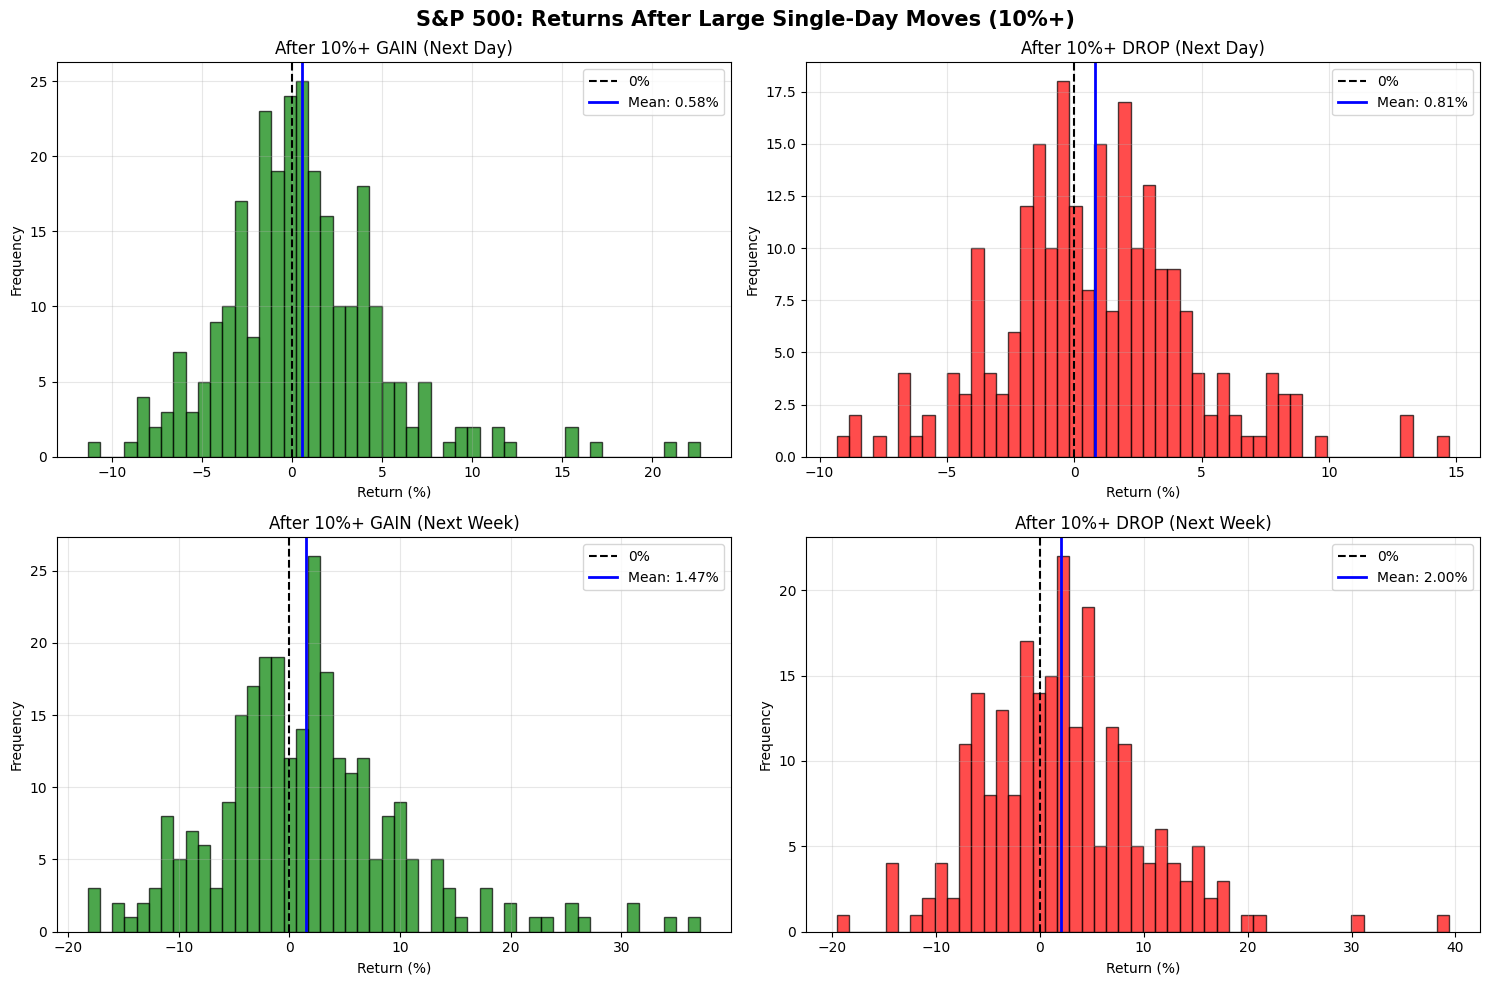

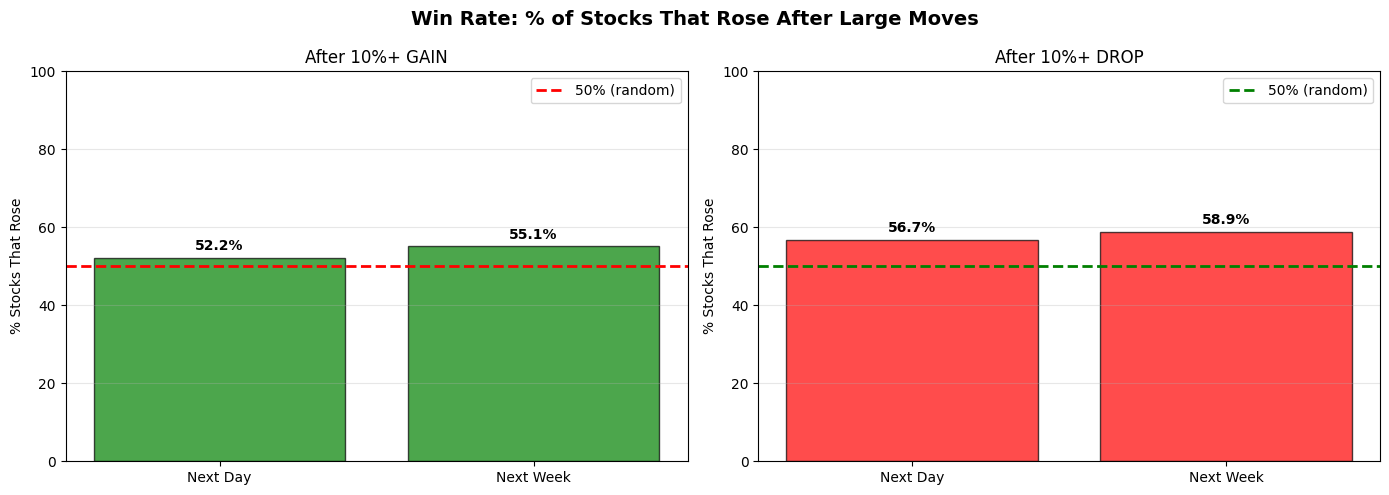

In [45]:
# Main Program

end_date = datetime.now()
start_date = end_date - timedelta(days=365)

print("-" * 65)
print("S&P 500 LARGE MOVEMENT ANALYSIS")
print("-" * 65 + "\n")

tickers   = get_sp500_tickers()
print(f"Fetched {len(tickers)} tickers\n")

data = download_stock_data(tickers, start_date, end_date)
spy = download_spy(start_date, end_date)
events_df = build_events_df(tickers, data, THRESHOLD, HOLD_DAYS)

if events_df.empty:
    print("No events found.")
else:
    drops = run_analysis(events_df, spy)

    print("\nGenerating visualizations...")
    create_visualizations(events_df)

  MEAN REVERSION BACKTEST



[                       0%                       ]

Fetched 503 tickers



[*********************100%***********************]  503 of 503 completed



Building price matrix...
Running backtest...
  Sharpe ratio:       1.94
  SPY Sharpe ratio:   1.95

  BACKTEST RESULTS
  Starting capital:   $100,000
  Final value:        $132,094
  Strategy return:    +32.1%
  SPY return:         +32.0%
  Outperformance:     +0.1%
  Max drawdown:       -6.6%
  Sharpe ratio:       1.94

Generating chart...


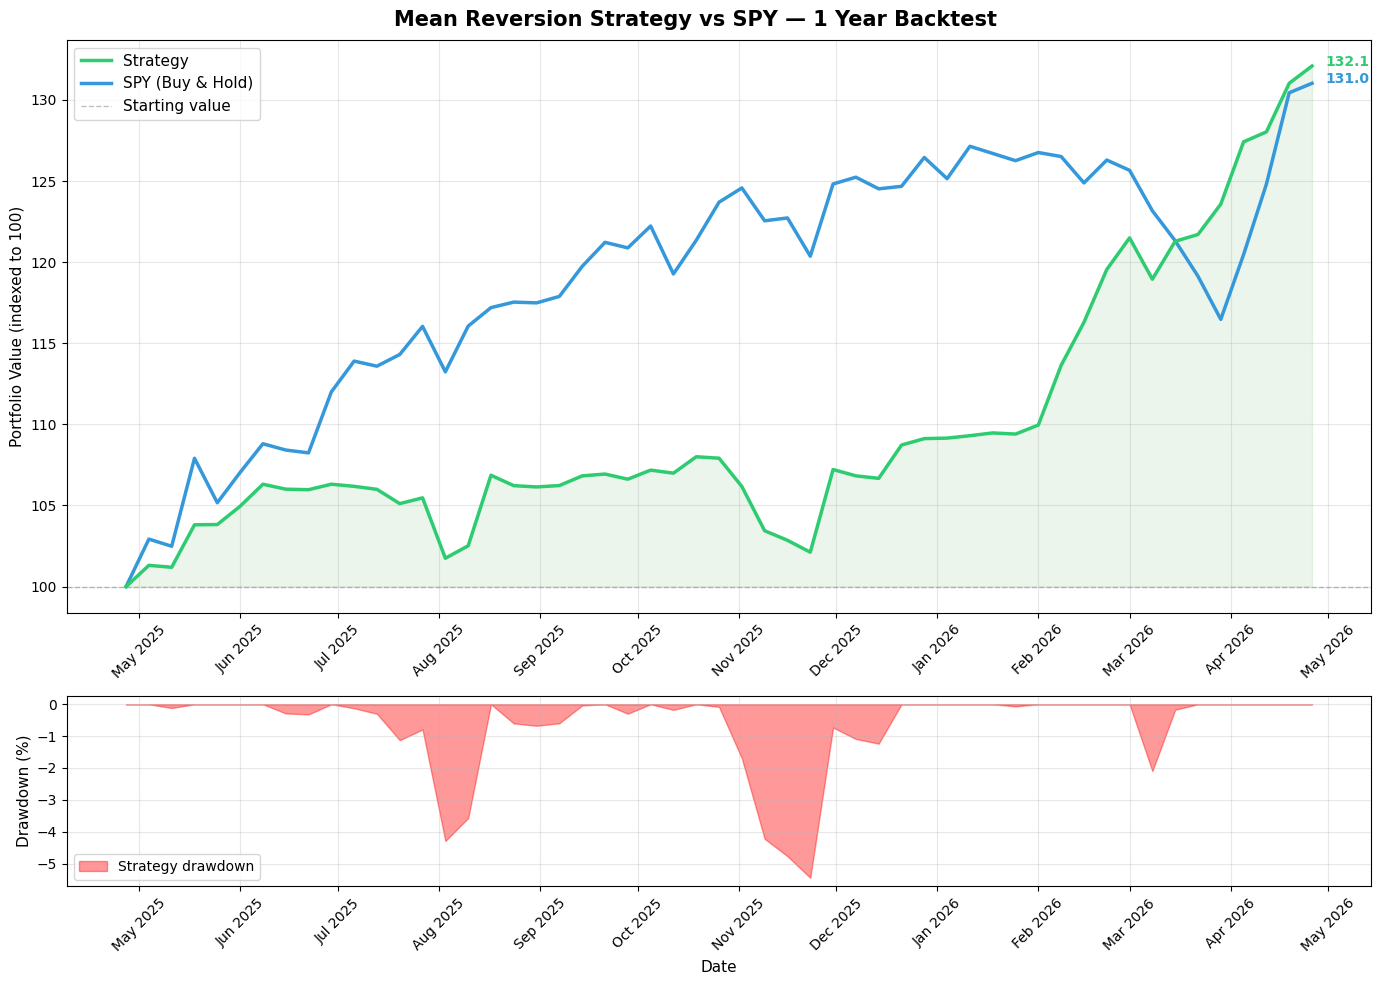

In [23]:
# =============================================================================
# S&P 500 Post-Shock Mean Reversion — Backtest
# Simulates the strategy over the last year and plots portfolio vs SPY
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from io import StringIO
import requests

# =============================================================================
# CONFIGURATION
# =============================================================================

STARTING_CAPITAL    = 100_000      # starting portfolio value ($)
POSITION_SIZE_PCT   = 0.06        # 3% of portfolio per trade (half Kelly)
THRESHOLD           = 0.10         # 10% single-day drop to trigger entry
HOLD_DAYS           = 5            # trading days to hold each position
TRANSACTION_COST    = 0.00        # 0.4% round-trip friction per trade

# =============================================================================
# TICKERS
# =============================================================================

def get_sp500_tickers():
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
        response = requests.get(url, headers=headers)
        tables = pd.read_html(StringIO(response.text))
        tickers = tables[0]['Symbol'].tolist()
        return [t.replace('.', '-') for t in tickers]
    except:
        print("WARNING: Could not fetch S&P 500 list. Using fallback subset.")
        return [
            'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'LLY', 'AVGO',
            'JPM', 'V', 'UNH', 'XOM', 'WMT', 'MA', 'JNJ', 'PG', 'COST', 'HD',
            'NFLX', 'BAC', 'ABBV', 'CRM', 'KO', 'ORCL', 'MRK', 'CVX', 'AMD', 'PEP',
            'ACN', 'ADBE', 'TMO', 'LIN', 'MCD', 'CSCO', 'DIS', 'ABT', 'WFC', 'INTC',
            'QCOM', 'VZ', 'DHR', 'TXN', 'CMCSA', 'PM', 'INTU', 'AMGN', 'IBM', 'COP',
            'NEE', 'HON', 'UNP', 'RTX', 'LOW', 'CAT', 'SPGI', 'AMAT', 'PFE', 'BA',
            'GE', 'UBER', 'BLK', 'DE', 'T', 'ELV', 'SYK', 'AXP', 'MS', 'MDT',
            'BKNG', 'GILD', 'TJX', 'PLD', 'VRTX', 'ADI', 'CI', 'SCHW', 'REGN', 'MMC',
            'C', 'LRCX', 'CB', 'SBUX', 'FI', 'ISRG', 'SO', 'MO', 'BMY', 'NOC',
            'AMT', 'PYPL', 'ETN', 'BSX', 'DUK', 'WM', 'ZTS', 'PGR', 'ITW', 'EOG',
            'APH', 'CME', 'BDX', 'AON', 'CL', 'CSX', 'MCO', 'GD', 'EMR', 'EQIX',
            'MMM', 'ICE', 'SLB', 'PH', 'HCA', 'NSC', 'USB', 'PSA', 'MDLZ', 'APD',
            'TGT', 'SHW', 'MAR', 'KLAC', 'GM', 'ECL', 'SNPS', 'MSI', 'WELL', 'ADM',
            'MCK', 'ADP', 'MPC', 'F', 'ROP', 'CDNS', 'TT', 'CCI', 'NXPI', 'ORLY',
            'COIN', 'AJG', 'TDG', 'PCAR', 'PSX', 'AFL', 'OKE', 'JCI', 'FDX', 'CMG',
            'AIG', 'SRE', 'FTNT', 'AZO', 'TRV', 'TEL', 'MNST', 'HUM', 'D', 'KMB',
            'ROST', 'AEP', 'PAYX', 'ALL', 'GIS', 'MSCI', 'SPG', 'HLT', 'CARR', 'O',
            'KMI', 'NEM', 'ANET', 'PRU', 'CTVA', 'FAST', 'DLR', 'BK', 'YUM', 'EA',
            'PCG', 'SYY', 'ODFL', 'CMI', 'IDXX', 'RSG', 'KHC', 'VRSK', 'CPRT', 'KR',
            'DD', 'CTAS', 'IT', 'GWW', 'OTIS', 'XEL', 'MCHP', 'EW', 'AME', 'BKR',
            'KEYS', 'HES', 'VMC', 'A', 'EXC', 'IQV', 'ROK', 'ACGL', 'RMD', 'VICI',
            'HSY', 'DOW', 'PPG', 'TROW', 'MTD', 'GEHC', 'ANSS', 'DVN', 'GLW', 'IR',
            'WMB', 'MLM', 'HAL', 'WTW', 'EXR', 'PWR', 'FANG', 'EFX', 'LHX', 'LVS',
            'DXCM', 'ED', 'CEG', 'CHTR', 'DAL', 'STZ', 'HPQ', 'CTSH', 'DHI', 'CAH',
            'URI', 'LEN', 'CBRE', 'VLO', 'FTV', 'WAB', 'DFS', 'CDW', 'WEC', 'TSCO',
            'ETR', 'SBAC', 'TTWO', 'BIIB', 'HPE', 'STT', 'LYB', 'MPWR', 'AEE', 'TRGP'
        ]

# =============================================================================
# DATA DOWNLOAD
# =============================================================================

def download_all_data(tickers, start_date, end_date):
    print(f"Downloading data for {len(tickers)} stocks...")
    data = yf.download(tickers, start=start_date, end=end_date, progress=True, group_by='ticker')
    spy  = yf.download('SPY', start=start_date, end=end_date, progress=False)
    spy.index = pd.to_datetime(spy.index)
    spy.columns = spy.columns.droplevel(1) if isinstance(spy.columns, pd.MultiIndex) else spy.columns  # <-- add this
    return data, spy

# =============================================================================
# BACKTEST ENGINE
# =============================================================================

def run_backtest(tickers, data, spy, starting_capital):

    # Build a clean price matrix — one column per ticker
    print("\nBuilding price matrix...")
    prices = {}
    for ticker in tickers:
        try:
            col = data[ticker]['Close'] if isinstance(data.columns, pd.MultiIndex) else data['Close']
            if len(col.dropna()) >= 10:
                prices[ticker] = col
        except:
            continue
    prices = pd.DataFrame(prices).sort_index()
    prices.index = pd.to_datetime(prices.index)

    trading_days = prices.index
    spy_close    = spy['Close'].reindex(trading_days).ffill()

    # Portfolio state
    portfolio_value = starting_capital
    cash            = starting_capital
    open_trades     = []   # list of dicts: {ticker, entry_date, exit_date, shares, entry_price, position_value}

    # Track portfolio value daily
    daily_values = {}

    print("Running backtest...")

    for day_idx in range(1, len(trading_days)):
        today     = trading_days[day_idx]
        yesterday = trading_days[day_idx - 1]

        # --- 1. Close any trades whose hold period is up ---
        still_open = []
        for trade in open_trades:
            if today >= trade['exit_date']:
                exit_price = prices.loc[today, trade['ticker']]
                if pd.isna(exit_price):
                    still_open.append(trade)
                    continue
                raw_return   = (exit_price - trade['entry_price']) / trade['entry_price']
                net_return   = raw_return - TRANSACTION_COST
                trade_pnl    = trade['position_value'] * net_return
                cash        += trade['position_value'] + trade_pnl
            else:
                still_open.append(trade)
        open_trades = still_open

        # --- 2. Recalculate portfolio value (cash + mark-to-market open trades) ---
        mtm = 0
        for trade in open_trades:
            current_price = prices.loc[today, trade['ticker']]
            if not pd.isna(current_price):
                mtm += trade['position_value'] * (current_price / trade['entry_price'])
            else:
                mtm += trade['position_value']
        portfolio_value = cash + mtm

        # --- 3. Scan for new entry signals ---
        for ticker in prices.columns:
            price_today     = prices.loc[today, ticker]
            price_yesterday = prices.loc[yesterday, ticker]

            if pd.isna(price_today) or pd.isna(price_yesterday) or price_yesterday == 0:
                continue

            daily_return = (price_today - price_yesterday) / price_yesterday

            if daily_return <= -THRESHOLD:
                # Check how many trading days forward we can go for exit
                future_idx = day_idx + HOLD_DAYS
                if future_idx >= len(trading_days):
                    continue
                exit_date = trading_days[future_idx]

                position_value = portfolio_value * POSITION_SIZE_PCT

                # Don't open if we don't have the cash
                if position_value > cash:
                    continue

                cash -= position_value
                open_trades.append({
                    'ticker':         ticker,
                    'entry_date':     today,
                    'exit_date':      exit_date,
                    'entry_price':    price_today,
                    'position_value': position_value,
                })

        daily_values[today] = portfolio_value

    # Close any remaining open trades at last price
    last_day = trading_days[-1]
    for trade in open_trades:
        exit_price = prices.loc[last_day, trade['ticker']]
        if not pd.isna(exit_price):
            raw_return = (exit_price - trade['entry_price']) / trade['entry_price']
            net_return = raw_return - TRANSACTION_COST
            cash      += trade['position_value'] + trade['position_value'] * net_return
        else:
            cash += trade['position_value']
    daily_values[last_day] = cash

    portfolio_series = pd.Series(daily_values).sort_index()
    return portfolio_series

# =============================================================================
# WEEKLY RESAMPLING
# =============================================================================

def to_weekly(series):
    return series.resample('W').last().dropna()

# =============================================================================
# SUMMARY STATS
# =============================================================================

def print_summary(portfolio_series, spy_series, starting_capital):
    final_value    = portfolio_series.iloc[-1]
    total_return   = (final_value - starting_capital) / starting_capital * 100
    spy_start      = float(spy_series.iloc[0])
    spy_end        = float(spy_series.iloc[-1])
    spy_return     = (spy_end - spy_start) / spy_start * 100

    # Max drawdown
    rolling_max    = portfolio_series.cummax()
    drawdown       = (portfolio_series - rolling_max) / rolling_max * 100
    max_drawdown   = drawdown.min()

    # Sharpe ratio (annualized, risk-free rate ~4.3% currently)
    daily_returns  = portfolio_series.pct_change().dropna()
    risk_free_daily = 0.043 / 252
    excess_returns  = daily_returns - risk_free_daily
    sharpe          = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)
    # SPY Sharpe
    spy_daily_returns   = spy_series.pct_change().dropna()
    spy_excess_returns  = spy_daily_returns - risk_free_daily
    spy_sharpe          = (spy_excess_returns.mean() / spy_excess_returns.std()) * np.sqrt(252)

    print(f"  Sharpe ratio:       {float(sharpe):.2f}")
    print(f"  SPY Sharpe ratio:   {float(spy_sharpe):.2f}")

    print("\n" + "=" * 55)
    print("  BACKTEST RESULTS")
    print("=" * 55)
    print(f"  Starting capital:   ${starting_capital:,.0f}")
    print(f"  Final value:        ${final_value:,.0f}")
    print(f"  Strategy return:    {total_return:+.1f}%")
    print(f"  SPY return:         {spy_return:+.1f}%")
    print(f"  Outperformance:     {total_return - spy_return:+.1f}%")
    print(f"  Max drawdown:       {max_drawdown:.1f}%")
    print(f"  Sharpe ratio:       {float(sharpe):.2f}")
    print("=" * 55)

# =============================================================================
# VISUALISATION
# =============================================================================

def plot_results(portfolio_weekly, spy_weekly, starting_capital):
    # Normalise both to 100 at start
    port_norm = portfolio_weekly / portfolio_weekly.iloc[0] * 100
    spy_norm = spy_weekly / spy_weekly.iloc[0] * 100  # remove the float() wrapper
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle('Mean Reversion Strategy vs SPY — 1 Year Backtest', fontsize=15, fontweight='bold')

    # --- Top: Portfolio growth ---
    ax1.plot(port_norm.index, port_norm.values, color='#2ecc71', linewidth=2.5, label='Strategy', zorder=3)
    ax1.plot(spy_norm.index,  spy_norm.values,  color='#3498db', linewidth=2.5, label='SPY (Buy & Hold)', zorder=2)
    ax1.axhline(100, color='grey', linestyle='--', linewidth=1, alpha=0.5, label='Starting value')
    ax1.fill_between(port_norm.index, port_norm.values, 100,
                     where=(port_norm.values >= 100), alpha=0.08, color='green')
    ax1.fill_between(port_norm.index, port_norm.values, 100,
                     where=(port_norm.values < 100),  alpha=0.08, color='red')
    ax1.set_ylabel('Portfolio Value (indexed to 100)', fontsize=11)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # Annotate final values
    ax1.annotate(f"{port_norm.iloc[-1]:.1f}",
                 xy=(port_norm.index[-1], port_norm.iloc[-1]),
                 xytext=(10, 0), textcoords='offset points',
                 color='#2ecc71', fontweight='bold', fontsize=10)
    ax1.annotate(f"{spy_norm.iloc[-1]:.1f}",
                 xy=(spy_norm.index[-1], spy_norm.iloc[-1]),
                 xytext=(10, 0), textcoords='offset points',
                 color='#3498db', fontweight='bold', fontsize=10)

    # --- Bottom: Drawdown ---
    rolling_max = portfolio_weekly.cummax()
    drawdown    = (portfolio_weekly - rolling_max) / rolling_max * 100
    ax2.fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.4, label='Strategy drawdown')
    ax2.set_ylabel('Drawdown (%)', fontsize=11)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()

# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    end_date   = datetime.now()
    start_date = end_date - timedelta(days=365)

    print("=" * 55)
    print("  MEAN REVERSION BACKTEST")
    print("=" * 55 + "\n")

    tickers          = get_sp500_tickers()
    print(f"Fetched {len(tickers)} tickers\n")

    data, spy        = download_all_data(tickers, start_date, end_date)
    portfolio_series = run_backtest(tickers, data, spy, STARTING_CAPITAL)

    portfolio_weekly = to_weekly(portfolio_series)
    spy_weekly       = to_weekly(spy['Close'])

    print_summary(portfolio_series, spy['Close'], STARTING_CAPITAL)

    print("\nGenerating chart...")
    plot_results(portfolio_weekly, spy_weekly, STARTING_CAPITAL)